In [1]:
import pandas as pd
import numpy as np
import json
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules


In [2]:
predicted_df = pd.read_csv('regions_labels_predicted.csv')
trait_json = open('Lythrum_traits_standardized.json')
traits = json.load(trait_json)

In [3]:
predicted_df.head()

,image_path,cluster_id,leaf,flower,stem,hand,background/undefined,filename,obs_id,group,y_true,y_pred
0,lythrum_virgatum_1111.jpeg_region_2.png,25,1.0,NaN,1.0,NaN,NaN,lythrum_virgatum_1111.jpeg,33281,lythrum_virgatum,0,0
1,lythrum_salicaria_7620.jpg_region_1.png,19,1.0,NaN,1.0,NaN,NaN,lythrum_salicaria_7620.jpg,7619,lythrum_salicaria,0,0
2,lythrum_alatum_5059.jpeg_region_2.png,27,NaN,NaN,NaN,NaN,1.0,lythrum_alatum_5059.jpeg,39768,lythrum_alatum,1,1
3,lythrum_salicaria_4752.jpeg_region_2.png,12,1.0,NaN,1.0,NaN,NaN,lythrum_salicaria_4752.jpeg,4751,lythrum_salicaria,0,1
4,lythrum_alatum_2102.jpeg_region_9.png,25,1.0,NaN,1.0,NaN,NaN,lythrum_alatum_2102.jpeg,36811,lythrum_alatum,1,1


In [4]:
label_columns = ['leaf', 'flower', 'stem', 'hand', 'background/undefined']
info_columns = ['filename', 'obs_id', 'group', 'y_true', 'y_pred']
predicted_df['group'] = predicted_df['group'].str.replace('_', ' ')

def get_characteristic_traits(row, traits_dict):
    species = row['group']  # species
    traits_for_species = traits_dict.get(species, {})
    collected_traits = []
    for label in ['leaf', 'flower', 'stem']:  # only biological traits
        if row[label] == 1:
            label_key = label if label in traits_for_species  else None
            if label_key:
                collected_traits.extend(traits_for_species[label_key])
    return collected_traits

merged_df = predicted_df[info_columns + ['hand', 'background/undefined']].copy()
merged_df['characteristic_traits'] = predicted_df.apply(lambda row: get_characteristic_traits(row, traits), axis=1)
print(merged_df.head())

                      filename  obs_id              group  y_true  y_pred  \
0   lythrum_virgatum_1111.jpeg   33281   lythrum virgatum       0       0   
1   lythrum_salicaria_7620.jpg    7619  lythrum salicaria       0       0   
2     lythrum_alatum_5059.jpeg   39768     lythrum alatum       1       1   
3  lythrum_salicaria_4752.jpeg    4751  lythrum salicaria       0       1   
4     lythrum_alatum_2102.jpeg   36811     lythrum alatum       1       1   

   hand  background/undefined  \
0   NaN                   NaN   
1   NaN                   NaN   
2   NaN                   1.0   
3   NaN                   NaN   
4   NaN                   NaN   

                               characteristic_traits  
0  [leaves opposite, sessilee, getting narrower a...  
1  [leaves opposite, sessilee, alternate distally...  
2                                                 []  
3  [leaves opposite, sessilee, alternate distally...  
4  [leaves opposite, becoming alternate distally,...  


In [5]:
merged_df.columns

Index(['filename', 'obs_id', 'group', 'y_true', 'y_pred', 'hand',
       'background/undefined', 'characteristic_traits'],
      dtype='object')

# First try with association rules

In [7]:
df = merged_df.copy()
def classification_outcome(row):
    if row['y_true'] == 1 and row['y_pred'] == 1:
        return 'TP'   # correctly classified as present
    elif row['y_true'] == 0 and row['y_pred'] == 0:
        return 'TN'   # correctly classified as absent
    elif row['y_true'] == 1 and row['y_pred'] == 0:
        return 'FN'   # false negative
    elif row['y_true'] == 0 and row['y_pred'] == 1:
        return 'FP'   # false positive
    else:
        return 'Unknown'

df['classification_outcome'] = df.apply(classification_outcome, axis=1)


# collect all traits per row as list
transactions = df['characteristic_traits'].tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
traits_df = pd.DataFrame(te_ary, columns=te.columns_)

# add hand and background/undefined as binary
traits_df['hand'] = df['hand']
traits_df['background_undefined'] = df['background/undefined']

# add target variable for rule mining
traits_df['classification_outcome'] = df['classification_outcome']
traits_boolean_df = traits_df.drop(columns=['classification_outcome']).fillna(False).astype(bool)


def find_rules(df, classification_outcome, min_support=0.01, metric="confidence", min_threshold=0.4):

    frequent_itemsets = apriori(traits_boolean_df, min_support=0.01, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

    rules = rules[rules['consequents'].apply(lambda x: classification_outcome in x)]

    return rules

In [16]:
traits_boolean_df.columns

Index(['4 minute petals',
       'a discernible gap between the stem and the base of the blade',
       'alternate distally', 'base attenuate', 'base narrowly attenuate',
       'base obtuse to truncate', 'base rounded',
       'becoming alternate distally', 'broader at the base',
       'calyx with alternate long and small teeth',
       'calyx with teeth of the same length', 'distally alternate',
       'floral tube campanulate', 'floral tube cylindrical',
       'floral tube narrowly obconic without red dots', 'floral tube obconic',
       'floral tube obconic without red dots',
       'flower tube narrowly cylindrical without red dots', 'flowers solitary',
       'getting narrower at the base', 'inflorescence raceme',
       'inflorescence spikelike', 'inflorescence sspikelike',
       'inflorescence sspikelike to raceme', 'leaves alternate',
       'leaves mostly alternate', 'leaves opposite',
       'leaves opposite but sometimes alternate', 'leaves sessilee',
       'leaves with

In [15]:
tp_traits_boolean

,4 minute petals,a discernible gap between the stem and the base of the blade,alternate distally,base attenuate,base narrowly attenuate,base obtuse to truncate,base rounded,becoming alternate distally,broader at the base,calyx with alternate long and small teeth,...,stamens 5-8,stamens 6,stamens 6-8,stamens 8,subsessilee,subsessileee,usually with a darker midrib,with flowers in whorled clusters,hand,background_undefined
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132121,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
132122,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
132124,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
132125,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [9]:
supports = [0.1, 0.05, 0.01, 0.005, 0.001]
thresholds = [0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

tp_traits_boolean = traits_boolean_df[traits_df['classification_outcome'] == 'TP']
tn_traits_boolean = traits_boolean_df[traits_df['classification_outcome'] == 'TN']
fp_traits_boolean = traits_boolean_df[traits_df['classification_outcome'] == 'FP']
fn_traits_boolean = traits_boolean_df[traits_df['classification_outcome'] == 'FN']

for s in supports:
    for t in thresholds:

        print(f"Config: support {s}; threshold {t}")

        tp_rules = find_rules(tp_traits_boolean, 'TP', min_support=s, min_threshold=t)
        tn_rules = find_rules(tn_traits_boolean, 'TN', min_support=s, min_threshold=t)
        fp_rules = find_rules(fp_traits_boolean, 'FP', min_support=s, min_threshold=t)
        fn_rules = find_rules(fn_traits_boolean, 'FN', min_support=s, min_threshold=t)

        print("TP Rules:")
        print(tp_rules)
        print("\nTN Rules:")
        print(tn_rules)
        print("\nFP Rules:")
        print(fp_rules)
        print("\nFN Rules:")
        print(fn_rules)

Config: support 0.1; threshold 0.6
TP Rules:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []

TN Rules:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []

FP Rules:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []

FN Rules:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []
Config: support 0.1; threshold 0.5
TP Rules:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []

TN Rules:
Empty DataFrame
Columns: [antecedent

# Let's try something more structured

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

class ImprovedPlantModelAnalyzer:
    def __init__(self, df):
        """
        Initialize analyzer with plant invasiveness dataframe
        Expected columns: 'filename', 'obs_id', 'group', 'y_true', 'y_pred', 
                         'hand', 'background/undefined', 'characteristic_traits'
        """
        self.df = df.copy()
        self.prepare_data()
        
    def prepare_data(self):
        """Prepare data for analysis"""
        print("Preparing data...")
        
        # Create model correctness indicator
        self.df['correct_prediction'] = (self.df['y_true'] == self.df['y_pred']).astype(int)
        
        # Create error type column
        self.df['error_type'] = 'Correct'
        self.df.loc[(self.df['y_true'] == 0) & (self.df['y_pred'] == 1), 'error_type'] = 'False Positive'
        self.df.loc[(self.df['y_true'] == 1) & (self.df['y_pred'] == 0), 'error_type'] = 'False Negative'
        
        # Process characteristic traits if they're in list format
        if isinstance(self.df['characteristic_traits'].iloc[0], str):
            # If stored as string representation of list, convert
            self.df['characteristic_traits'] = self.df['characteristic_traits'].apply(
                lambda x: eval(x) if x.startswith('[') else [x] if pd.notna(x) else []
            )
        
        # Create binary columns for each unique trait
        all_traits = set()
        for traits in self.df['characteristic_traits'].dropna():
            if isinstance(traits, list):
                all_traits.update(traits)
            else:
                all_traits.add(traits)
        
        self.all_traits = sorted(list(all_traits))
        
        # Create binary trait columns
        for trait in self.all_traits:
            self.df[f'has_{trait}'] = self.df['characteristic_traits'].apply(
                lambda x: 1 if isinstance(x, list) and trait in x else 0
            )
        
        print(f"Dataset prepared: {len(self.df)} samples, {len(self.all_traits)} unique traits")
    
    def summarize_trait_impact(self, top_n=10):
        """
        CLEAR SUMMARY: How each trait affects model accuracy
        Shows the TOP traits that make the biggest difference in accuracy
        """
        print("=" * 60)
        print("TRAIT IMPACT SUMMARY")
        print("=" * 60)
        print("This shows how much each trait helps or hurts model accuracy")
        print("Positive = trait improves accuracy, Negative = trait hurts accuracy")
        print()
        
        trait_impacts = []
        
        for trait in self.all_traits:
            trait_col = f'has_{trait}'
            
            # Plants WITH this trait
            with_trait = self.df[self.df[trait_col] == 1]
            # Plants WITHOUT this trait
            without_trait = self.df[self.df[trait_col] == 0]
            
            if len(with_trait) >= 5:  # Only consider traits with enough samples
                acc_with = with_trait['correct_prediction'].mean()
                acc_without = without_trait['correct_prediction'].mean()
                difference = acc_with - acc_without
                
                # Statistical significance test
                if len(with_trait) > 0 and len(without_trait) > 0:
                    contingency = pd.crosstab(self.df[trait_col], self.df['correct_prediction'])
                    if contingency.shape[0] == 2 and contingency.shape[1] == 2:
                        # Safe to run chi-square
                        _, p_value = stats.chi2_contingency(contingency)[:2]
                    else:
                        p_value = 1.0  # no variation → not testable
                else:
                    p_value = 1.0
                
                trait_impacts.append({
                    'trait': trait,
                    'accuracy_with_trait': acc_with,
                    'accuracy_without_trait': acc_without,
                    'impact': difference,
                    'p_value': p_value,
                    'sample_size': len(with_trait),
                    'significant': 'Yes' if p_value < 0.05 else 'No'
                })
        
        # Convert to DataFrame and sort by impact
        impact_df = pd.DataFrame(trait_impacts).sort_values('impact', key=abs, ascending=False)
        
        print(f"TOP {top_n} MOST IMPACTFUL TRAITS:")
        print("-" * 80)
        for i, row in impact_df.head(top_n).iterrows():
            direction = "HELPS" if row['impact'] > 0 else "HURTS"
            significance = f"(p={row['p_value']:.3f})" if row['p_value'] < 0.05 else "(not significant)"
            
            print(f"{row['trait']:25} {direction:5} accuracy by {abs(row['impact']):+.3f} {significance}")
            print(f"                         With trait: {row['accuracy_with_trait']:.3f} | "
                  f"Without trait: {row['accuracy_without_trait']:.3f} | "
                  f"Samples: {row['sample_size']}")
            print()
        
        return impact_df
    
    def analyze_hand_background_labels(self):
        """
        Improved: Impact of 'hand' and 'background/undefined' labels.
        - Treats NaNs as an explicit 'Missing' category and reports its size.
        - Shows accuracy, precision, recall per label value.
        - Computes effect sizes and runs Chi-square / Fisher as appropriate.
        """
        print("=" * 60)
        print("ANNOTATION LABEL IMPACT ANALYSIS")
        print("=" * 60)
        print("This analyzes how annotation quality affects model performance")
        print()

        # Work on a local copy so we don't permanently mutate self.df unexpectedly
        df = self.df.copy()

        # Create explicit label columns where NaN -> 'Missing' (string) for clear grouping
        df['hand_label'] = df['hand'].fillna('Missing').astype(str)
        df['bg_label'] = df['background/undefined'].fillna('Missing').astype(str)

        # Helper to compute precision/recall safely
        def compute_metrics(subset):
            if subset.empty:
                return (np.nan, np.nan)
            cm = confusion_matrix(subset['y_true'], subset['y_pred'], labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            return precision, recall

        # Generic label analysis routine
        def analyze_col(col_name, pretty_name):
            print(f"1. {pretty_name}" if 'HAND' in pretty_name else f"2. {pretty_name}")
            print(f"   (shows counts including missing values and performance metrics per value)")
            print()

            # Value counts including missing
            vc = df[col_name].value_counts(dropna=False)
            print("   Value counts (including Missing):")
            for val, cnt in vc.items():
                pct = cnt / len(df)
                print(f"     {str(val):12s} n={cnt:,} ({pct:.1%})")
            print()

            # Grouped metrics
            grouped = df.groupby(col_name).agg({
                'correct_prediction': ['count', 'mean'],
                'y_true': 'mean',
                'y_pred': 'mean'
            }).round(3)
            grouped.columns = ['sample_count', 'accuracy', 'true_invasive_rate', 'pred_invasive_rate']

            # Add precision & recall per group
            for val in grouped.index:
                prec, rec = compute_metrics(df[df[col_name] == val])
                grouped.loc[val, 'precision'] = round(prec, 3) if not np.isnan(prec) else np.nan
                grouped.loc[val, 'recall'] = round(rec, 3) if not np.isnan(rec) else np.nan

            # Print results
            print(f"   Results by {pretty_name.split()[0]} Label Value:")
            for val, row in grouped.iterrows():
                print(f"     {str(val):12s}: Acc={row['accuracy']:.3f}, "
                    f"Prec={row['precision']:.3f}, Rec={row['recall']:.3f} "
                    f"(n={int(row['sample_count']):,} samples)")
            print()

            # Effect size: prefer direct 1 vs 0 comparison if available, otherwise compare to 'Missing'
            acc_series = grouped['accuracy']
            p_val = None
            method = None
            if '1.0' in acc_series.index and '0.0' in acc_series.index:
                diff = acc_series.loc['1.0'] - acc_series.loc['0.0']
                print(f"   Accuracy difference (1.0 vs 0.0): {diff:+.3f}")
            else:
                # compare first non-missing value to Missing if both exist
                non_missing = [i for i in acc_series.index if i != 'Missing']
                if len(non_missing) >= 1 and 'Missing' in acc_series.index:
                    diff = acc_series.loc[non_missing[0]] - acc_series.loc['Missing']
                    print(f"   Accuracy difference ({non_missing[0]} vs Missing): {diff:+.3f}")
            print()

            # Build contingency table including 'Missing' (we filled it above)
            contingency = pd.crosstab(df[col_name], df['correct_prediction'], dropna=False)
            # Need at least 2 label groups and two outcome columns to run tests
            if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
                # If 2x2, consider Fisher when expected counts are small
                if contingency.shape == (2, 2):
                    chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
                    if (expected < 5).any():
                        # use Fisher exact for small expected counts
                        try:
                            oddsratio, p_fisher = stats.fisher_exact(contingency.values)
                            p_val = p_fisher
                            method = "Fisher exact (2x2, small expected)"
                        except Exception:
                            p_val = p_chi
                            method = "Chi-square (fallback)"
                    else:
                        p_val = p_chi
                        method = "Chi-square"
                else:
                    chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
                    p_val = p_chi
                    method = "Chi-square"

                significance = "SIGNIFICANT" if (p_val is not None and p_val < 0.05) else "NOT significant"
                print(f"   Statistical test: {method} => {significance} (p={p_val:.4f})")
            else:
                print("   Statistical test: NOT RUN - need >=2 label groups and >=2 outcome classes (0/1).")
                p_val = None

            print()
            return grouped, contingency, p_val

        # Run analyses for both columns
        hand_stats, hand_contingency, hand_p = analyze_col('hand_label', "'HAND' LABEL IMPACT:")
        bg_stats, bg_contingency, bg_p = analyze_col('bg_label', "'BACKGROUND/UNDEFINED' LABEL IMPACT:")

        results = {
            'hand_analysis': hand_stats,
            'background_analysis': bg_stats,
            'hand_contingency': hand_contingency,
            'background_contingency': bg_contingency,
            'hand_p_value': hand_p,
            'background_p_value': bg_p
        }

        return results



    
    def trait_combination_analysis_explained(self, min_samples=10):
        """
        CLEAR EXPLANATION: How combinations of traits affect model performance
        This shows which combinations of plant characteristics work best/worst together
        """
        print("=" * 60)
        print("TRAIT COMBINATION ANALYSIS")
        print("=" * 60)
        print("This shows how COMBINATIONS of plant traits affect model accuracy")
        print("For example: 'spiny, red flowers' vs 'smooth, white flowers'")
        print(f"Only showing combinations with at least {min_samples} samples")
        print()
        
        # Create trait combination strings
        self.df['trait_combo'] = self.df['characteristic_traits'].apply(
            lambda x: ', '.join(sorted(x)) if isinstance(x, list) and len(x) > 0 else 'No specific traits'
        )
        
        # Count number of traits per sample
        self.df['num_traits'] = self.df['characteristic_traits'].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )
        
        # Analyze combinations with enough samples
        combo_stats = self.df.groupby('trait_combo').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean',
            'num_traits': 'first'
        }).round(3)
        
        combo_stats.columns = ['sample_size', 'accuracy', 'actual_invasive_rate', 'num_traits']
        combo_stats = combo_stats[combo_stats['sample_size'] >= min_samples]
        combo_stats = combo_stats.sort_values('accuracy', ascending=False)
        
        print("BEST PERFORMING TRAIT COMBINATIONS:")
        print("-" * 50)
        for i, (combo, row) in enumerate(combo_stats.head(5).iterrows()):
            print(f"{i+1}. Traits: {combo}")
            print(f"   Accuracy: {row['accuracy']:.3f} ({row['sample_size']} samples)")
            print(f"   {row['actual_invasive_rate']*100:.1f}% are actually invasive")
            print()
        
        print("WORST PERFORMING TRAIT COMBINATIONS:")
        print("-" * 50)
        for i, (combo, row) in enumerate(combo_stats.tail(5).iterrows()):
            print(f"{i+1}. Traits: {combo}")
            print(f"   Accuracy: {row['accuracy']:.3f} ({row['sample_size']} samples)")
            print(f"   {row['actual_invasive_rate']*100:.1f}% are actually invasive")
            print()
        
        # Analysis by number of traits
        print("PERFORMANCE BY NUMBER OF TRAITS:")
        print("-" * 40)
        trait_count_analysis = self.df.groupby('num_traits').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean'
        }).round(3)
        trait_count_analysis.columns = ['sample_size', 'accuracy', 'actual_invasive_rate']
        
        for num_traits, row in trait_count_analysis.iterrows():
            if row['sample_size'] >= 5:
                print(f"   {num_traits} traits: Accuracy = {row['accuracy']:.3f} "
                      f"({row['sample_size']} samples)")
        
        return combo_stats
    
    def create_readable_visualizations(self):
        """
        Create clean, readable visualizations with limited data points
        """
        plt.style.use('default')
        fig = plt.figure(figsize=(16, 12))
        
        # 1. Top 10 most impactful traits
        plt.subplot(2, 3, 1)
        trait_impacts = []
        for trait in self.all_traits:
            trait_col = f'has_{trait}'
            with_trait = self.df[self.df[trait_col] == 1]
            without_trait = self.df[self.df[trait_col] == 0]
            
            if len(with_trait) >= 10:  # Only traits with enough samples
                diff = with_trait['correct_prediction'].mean() - without_trait['correct_prediction'].mean()
                trait_impacts.append((trait, diff, len(with_trait)))
        
        # Sort and take top 10
        trait_impacts = sorted(trait_impacts, key=lambda x: abs(x[1]), reverse=True)[:10]
        traits, impacts, sizes = zip(*trait_impacts)
        
        colors = ['green' if x > 0 else 'red' for x in impacts]
        bars = plt.barh(range(len(traits)), impacts, color=colors, alpha=0.7)
        plt.yticks(range(len(traits)), [f"{t[:15]}..." if len(t) > 15 else t for t in traits])
        plt.xlabel('Accuracy Impact')
        plt.title('Top 10 Most Impactful Traits')
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        
        # Add sample sizes as text
        for i, (bar, size) in enumerate(zip(bars, sizes)):
            plt.text(bar.get_width() + (0.01 if bar.get_width() >= 0 else -0.01), 
                    bar.get_y() + bar.get_height()/2, 
                    f'n={size}', ha='left' if bar.get_width() >= 0 else 'right', va='center', fontsize=8)
        
        # 2. Overall confusion matrix
        plt.subplot(2, 3, 2)
        cm = confusion_matrix(self.df['y_true'], self.df['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'shrink': 0.8})
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        
        # 3. Performance by annotation labels
        # 3. Performance by annotation labels (with Missing handled)
        plt.subplot(2, 3, 3)

        # Prepare hand and background with Missing as explicit category
        df_labels = self.df.copy()
        df_labels['hand_label'] = df_labels['hand'].fillna('Missing').astype(str)
        df_labels['bg_label'] = df_labels['background/undefined'].fillna('Missing').astype(str)

        hand_acc = df_labels.groupby('hand_label')['correct_prediction'].mean()
        bg_acc = df_labels.groupby('bg_label')['correct_prediction'].mean()

        # Align x positions
        labels = sorted(set(hand_acc.index).union(set(bg_acc.index)))
        x = np.arange(len(labels))

        bar_width = 0.35
        plt.bar(x - bar_width/2, [hand_acc.get(l, np.nan) for l in labels], 
                width=bar_width, label='Hand Label', alpha=0.7)
        plt.bar(x + bar_width/2, [bg_acc.get(l, np.nan) for l in labels], 
                width=bar_width, label='Background Label', alpha=0.7)

        plt.xlabel('Label Value')
        plt.ylabel('Accuracy')
        plt.title('Performance by Annotation Labels (incl. Missing)')
        plt.legend()
        plt.xticks(x, labels, rotation=30)

        
        # 4. Accuracy by number of traits
        plt.subplot(2, 3, 4)
        self.df['num_traits'] = self.df['characteristic_traits'].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )
        trait_count_acc = self.df.groupby('num_traits')['correct_prediction'].mean()
        trait_count_size = self.df.groupby('num_traits').size()
        
        # Only show counts with reasonable sample sizes
        valid_counts = trait_count_size[trait_count_size >= 10]
        
        plt.bar(valid_counts.index, trait_count_acc[valid_counts.index].values)
        plt.xlabel('Number of Traits')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Traits')
        
        # Add sample size labels
        for x, acc, size in zip(valid_counts.index, trait_count_acc[valid_counts.index], valid_counts):
            plt.text(x, acc + 0.01, f'n={size}', ha='center', va='bottom', fontsize=8)
        
        # 5. Top 10 worst performing species
        plt.subplot(2, 3, 5)
        species_acc = self.df.groupby('group').agg({
            'correct_prediction': ['mean', 'count']
        })
        species_acc.columns = ['accuracy', 'sample_size']
        species_acc = species_acc[species_acc['sample_size'] >= 5]  # Min 5 samples
        worst_species = species_acc.sort_values('accuracy').head(10)
        
        plt.barh(range(len(worst_species)), worst_species['accuracy'].values, color='coral')
        plt.yticks(range(len(worst_species)), 
                  [f"{name[:20]}..." if len(name) > 20 else name for name in worst_species.index])
        plt.xlabel('Accuracy')
        plt.title('Top 10 Worst Performing Species')
        
        # 6. Error types distribution
        plt.subplot(2, 3, 6)
        error_counts = self.df['error_type'].value_counts()
        plt.pie(error_counts.values, labels=error_counts.index, autopct='%1.1f%%')
        plt.title('Distribution of Prediction Results')
        
        plt.tight_layout()
        plt.show()
    
    def comprehensive_summary_report(self):
        """
        Generate a clear, comprehensive summary report
        """
        print("=" * 80)
        print("COMPREHENSIVE PLANT INVASIVENESS MODEL ANALYSIS REPORT")
        print("=" * 80)
        print()
        
        # Basic dataset info
        total_samples = len(self.df)
        overall_accuracy = self.df['correct_prediction'].mean()
        invasive_rate = self.df['y_true'].mean()
        num_species = self.df['group'].nunique()
        
        print("DATASET OVERVIEW:")
        print(f"  • Total samples: {total_samples:,}")
        print(f"  • Overall model accuracy: {overall_accuracy:.1%}")
        print(f"  • Invasive species rate in dataset: {invasive_rate:.1%}")
        print(f"  • Number of species: {num_species}")
        print(f"  • Number of unique traits: {len(self.all_traits)}")
        print()
        
        # Error breakdown
        error_counts = self.df['error_type'].value_counts()
        print("ERROR BREAKDOWN:")
        for error_type, count in error_counts.items():
            percentage = count / total_samples * 100
            print(f"  • {error_type}: {count:,} samples ({percentage:.1f}%)")
        print()
        
        # Run main analyses
        print("RUNNING DETAILED ANALYSES...")
        print()
        
        # 1. Trait impact analysis
        trait_impact_results = self.summarize_trait_impact(top_n=8)
        
        # 2. Label impact analysis  
        label_results = self.analyze_hand_background_labels()
        
        # 3. Trait combination analysis
        combo_results = self.trait_combination_analysis_explained(min_samples=8)
        
        # 4. Species performance
        print("=" * 60)
        print("SPECIES PERFORMANCE SUMMARY")
        print("=" * 60)
        
        species_stats = self.df.groupby('group').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean'
        }).round(3)
        species_stats.columns = ['sample_size', 'accuracy', 'actual_invasive_rate']
        species_stats = species_stats[species_stats['sample_size'] >= 5]
        
        # Problematic species (accuracy < 0.6)
        problematic = species_stats[species_stats['accuracy'] < 0.6].sort_values('accuracy')
        
        print(f"SPECIES WITH ACCURACY BELOW 60% ({len(problematic)} species):")
        print("-" * 60)
        for species, row in problematic.head(10).iterrows():
            print(f"  {species[:40]:40} | Acc: {row['accuracy']:.3f} | "
                  f"Samples: {int(row['sample_size']):3d} | "
                  f"Invasive rate: {row['actual_invasive_rate']:.1%}")
        
        print()
        
        # Best performing species
        excellent = species_stats[species_stats['accuracy'] > 0.9].sort_values('accuracy', ascending=False)
        print(f"SPECIES WITH ACCURACY ABOVE 90% ({len(excellent)} species):")
        print("-" * 60)
        for species, row in excellent.head(5).iterrows():
            print(f"  {species[:40]:40} | Acc: {row['accuracy']:.3f} | "
                  f"Samples: {int(row['sample_size']):3d} | "
                  f"Invasive rate: {row['actual_invasive_rate']:.1%}")
        
        print()
        
        # Generate clean visualizations
        self.create_readable_visualizations()
        
        # Key insights summary
        print("=" * 60)
        print("KEY INSIGHTS SUMMARY")
        print("=" * 60)
        
        # Most impactful trait
        top_trait = trait_impact_results.iloc[0]
        print(f"1. MOST IMPACTFUL TRAIT: '{top_trait['trait']}'")
        print(f"   → Changes accuracy by {abs(top_trait['impact']):.3f}")
        print(f"   → {'Helps' if top_trait['impact'] > 0 else 'Hurts'} model performance")
        print()
        
        # Label impact
        hand_significant = label_results['hand_p_value'] < 0.05
        bg_significant = label_results['background_p_value'] < 0.05
        print(f"2. ANNOTATION LABEL IMPACT:")
        print(f"   → Hand label: {'Significant' if hand_significant else 'Not significant'} effect")
        print(f"   → Background label: {'Significant' if bg_significant else 'Not significant'} effect")
        print()
        
        # Best/worst combinations
        if len(combo_results) > 0:
            best_combo = combo_results.iloc[0]
            worst_combo = combo_results.iloc[-1]
            print(f"3. TRAIT COMBINATIONS:")
            print(f"   → Best combo: {best_combo.name[:50]}... (acc: {best_combo['accuracy']:.3f})")
            print(f"   → Worst combo: {worst_combo.name[:50]}... (acc: {worst_combo['accuracy']:.3f})")
            print()
        
        # Most problematic species
        if len(problematic) > 0:
            worst_species = problematic.iloc[0]
            print(f"4. MOST PROBLEMATIC SPECIES: {worst_species.name}")
            print(f"   → Accuracy: {worst_species['accuracy']:.3f}")
            print(f"   → Sample size: {worst_species['sample_size']}")
        
        print()
        print("=" * 80)
        print("ANALYSIS COMPLETE")
        print("=" * 80)
        
        return {
            'trait_impacts': trait_impact_results,
            'label_analysis': label_results,
            'trait_combinations': combo_results,
            'species_performance': species_stats,
            'problematic_species': problematic
        }

Preparing data...
Dataset prepared: 132128 samples, 88 unique traits
COMPREHENSIVE PLANT INVASIVENESS MODEL ANALYSIS REPORT

DATASET OVERVIEW:
  • Total samples: 132,128
  • Overall model accuracy: 78.0%
  • Invasive species rate in dataset: 58.5%
  • Number of species: 29
  • Number of unique traits: 88

ERROR BREAKDOWN:
  • Correct: 103,103 samples (78.0%)
  • False Positive: 22,038 samples (16.7%)
  • False Negative: 6,987 samples (5.3%)

RUNNING DETAILED ANALYSES...

TRAIT IMPACT SUMMARY
This shows how much each trait helps or hurts model accuracy
Positive = trait improves accuracy, Negative = trait hurts accuracy

TOP 8 MOST IMPACTFUL TRAITS:
--------------------------------------------------------------------------------
getting narrower at the base HURTS accuracy by +0.243 (p=0.000)
                         With trait: 0.545 | Without trait: 0.788 | Samples: 4024

inflorescence sspikelike to raceme HURTS accuracy by +0.242 (p=0.000)
                         With trait: 0.542 | W

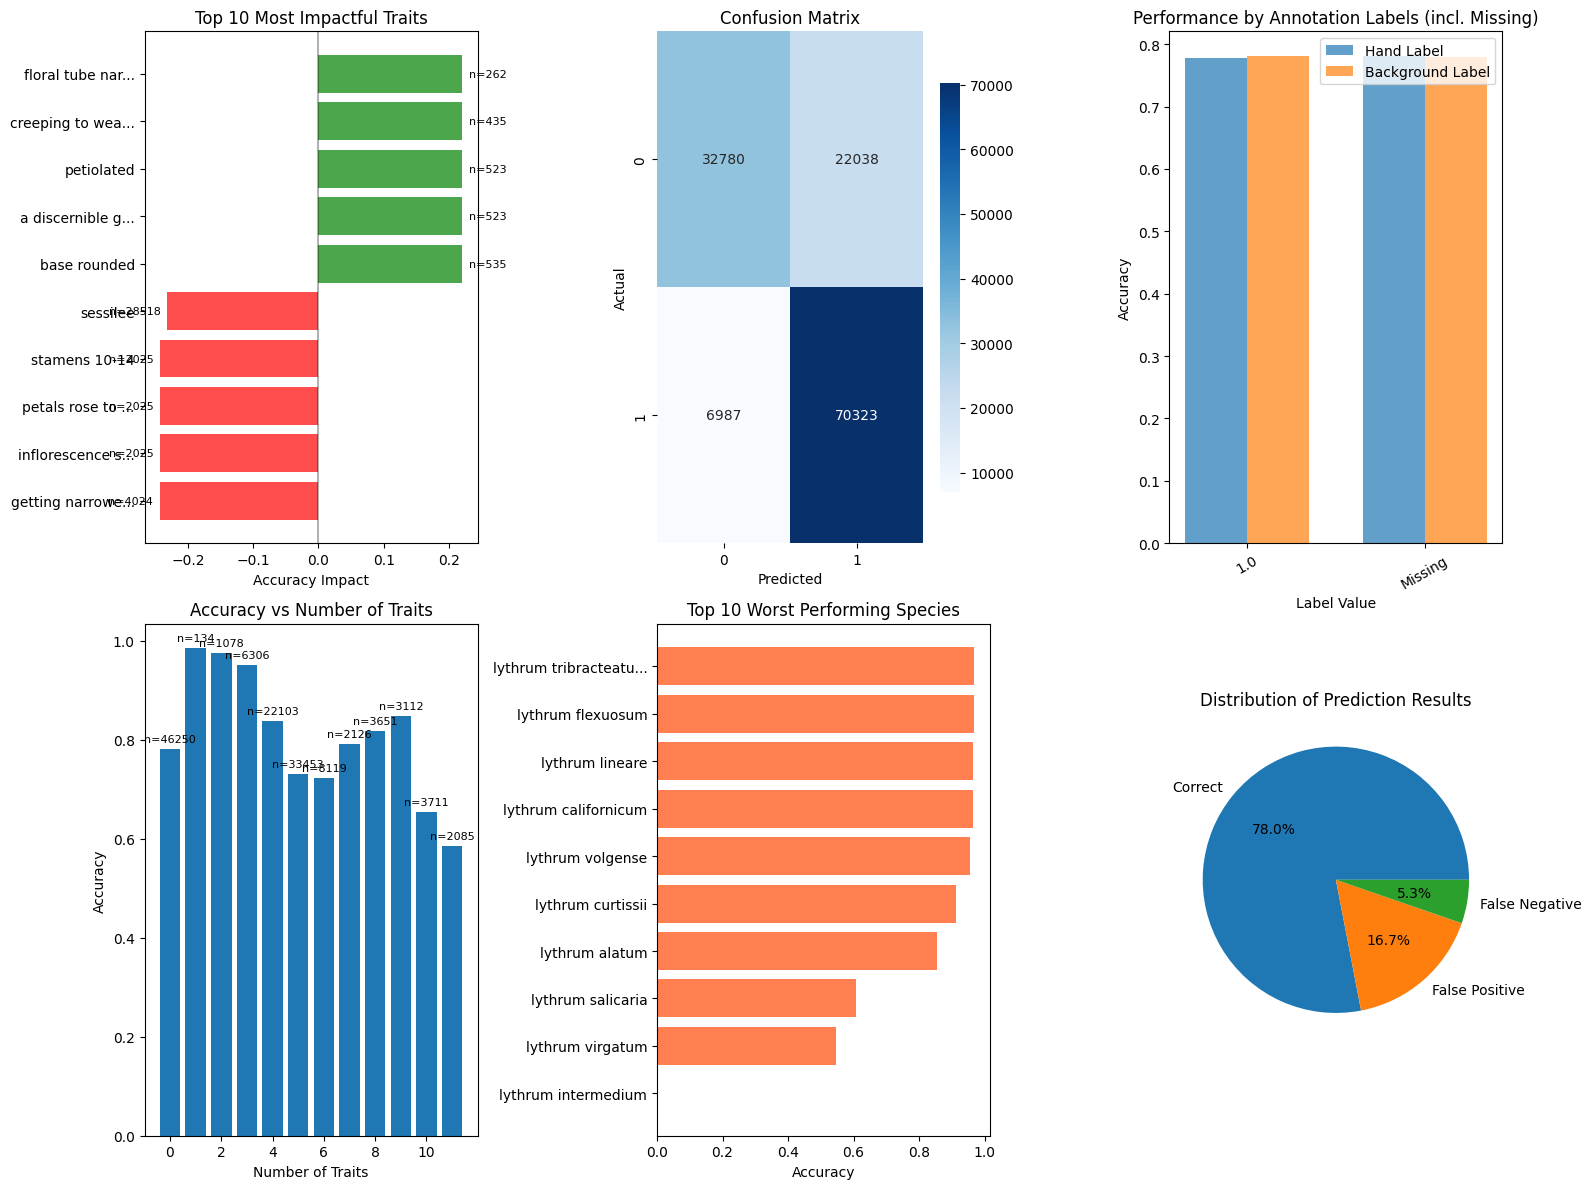

KEY INSIGHTS SUMMARY
1. MOST IMPACTFUL TRAIT: 'getting narrower at the base'
   → Changes accuracy by 0.243
   → Hurts model performance

2. ANNOTATION LABEL IMPACT:
   → Hand label: Not significant effect
   → Background label: Not significant effect

3. TRAIT COMBINATIONS:
   → Best combo: distally alternate, leaves opposite, petals pinkis... (acc: 1.000)
   → Worst combo: erect, floral tube cylindrical, inflorescence sspi... (acc: 0.477)

4. MOST PROBLEMATIC SPECIES: lythrum intermedium
   → Accuracy: 0.000
   → Sample size: 121.0

ANALYSIS COMPLETE
TRAIT IMPACT SUMMARY
This shows how much each trait helps or hurts model accuracy
Positive = trait improves accuracy, Negative = trait hurts accuracy

TOP 10 MOST IMPACTFUL TRAITS:
--------------------------------------------------------------------------------
getting narrower at the base HURTS accuracy by +0.243 (p=0.000)
                         With trait: 0.545 | Without trait: 0.788 | Samples: 4024

inflorescence sspikelike to race

In [21]:
analyzer = ImprovedPlantModelAnalyzer(merged_df)

results = analyzer.comprehensive_summary_report()

trait_impacts = analyzer.summarize_trait_impact(top_n=10)
label_analysis = analyzer.analyze_hand_background_labels()
combo_analysis = analyzer.trait_combination_analysis_explained(min_samples=10)

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

class EnhancedImageLevelAnalyzer:
    def __init__(self, df):
        """
        df = region-level dataframe with columns:
        ['filename','obs_id','group','y_true','y_pred',
         'hand','background/undefined','characteristic_traits']
        """
        self.df_regions = df.copy()
        self.df_images = self._aggregate_to_image_level()

        self._prepare_analysis_columns()

        for col in self.trait_cols_present:
            self.df_images[col] = self.df_images[col].fillna(0).astype(int)
    
    # ---------------- AGGREGATE TO IMAGE LEVEL ----------------
    def _aggregate_to_image_level(self):
        df = self.df_regions.copy()

        def parse_traits(x):
            if isinstance(x, float) and np.isnan(x):
                return []
            elif isinstance(x, (list, np.ndarray)):
                return [str(t).strip() for t in x]
            else:
                return [str(x).strip()]
        
        df['traits_list'] = df['characteristic_traits'].apply(parse_traits)

        grouped = []
        for obs_id, g in df.groupby('obs_id'):
            row = {}
            row['obs_id'] = obs_id
            row['group'] = g['group'].mode()[0]  # representative group
            row['n_regions'] = len(g)
            row['y_true'] = g['y_true'].mode()[0]
            row['y_pred'] = g['y_pred'].mode()[0]
            row['correct_prediction'] = int(row['y_true'] == row['y_pred'])
            row['error_type'] = ('Correct' if row['correct_prediction']==1 
                                 else 'False Positive' if row['y_true']==0 else 'False Negative')
            
            row['hand_frac'] = g['hand'].fillna(0).mean()
            row['background_frac'] = g['background/undefined'].fillna(0).mean()

            trait_counts = Counter([t for traits in g['traits_list'] for t in traits])
            total_regions = len(g)
            for trait, count in trait_counts.items():
                row[f'trait_{trait}_present'] = 1
                row[f'trait_{trait}_freq'] = count / total_regions
            
            grouped.append(row)

        return pd.DataFrame(grouped)
    
    # ---------------- PREPARE ANALYSIS COLUMNS ----------------
    def _prepare_analysis_columns(self):
        # Identify all traits
        self.trait_cols_present = [c for c in self.df_images.columns if c.endswith('_present')]
        self.trait_cols_freq = [c for c in self.df_images.columns if c.endswith('_freq')]
        
        # Create numeric error indicators
        self.df_images['error_numeric'] = self.df_images['error_type'].map({'Correct':0, 'False Positive':1, 'False Negative':2})
        
        # Number of traits per image
        self.df_images['num_traits'] = self.df_images[self.trait_cols_present].sum(axis=1)

    # ---------------- PERFORMANCE SUMMARY ----------------
    def summary_performance(self):
        acc = self.df_images['correct_prediction'].mean()
        print("="*60)
        print("IMAGE-LEVEL PERFORMANCE SUMMARY")
        print("="*60)
        print(f"Accuracy: {acc:.3f} (n={len(self.df_images)})")
        print(f"Correct predictions: {self.df_images['correct_prediction'].sum()} / {len(self.df_images)}")
        print("Error type counts:")
        print(self.df_images['error_type'].value_counts())
        print()
        return acc
    
    # ---------------- LABEL IMPACT ----------------
    def analyze_annotation_labels(self):
        print("="*60)
        print("ANNOTATION LABEL IMPACT (image-level)")
        print("="*60)
        
        for col, pretty in [('hand_frac','Hand'),('background_frac','Background')]:
            print(f"\nImpact of {pretty} label:")
            has_label = self.df_images[col] > 0
            acc_with = self.df_images[has_label]['correct_prediction'].mean()
            acc_without = self.df_images[~has_label]['correct_prediction'].mean()
            print(f"  With {pretty}:   Acc={acc_with:.3f} (n={has_label.sum()})")
            print(f"  Without {pretty}: Acc={acc_without:.3f} (n={(~has_label).sum()})")
            print(f"  Difference: {acc_with-acc_without:+.3f}")

            contingency = pd.crosstab(has_label, self.df_images['correct_prediction'])
            if contingency.shape == (2,2):
                chi2, p, _, _ = stats.chi2_contingency(contingency)
                signif = "SIGNIFICANT" if p<0.05 else "NOT significant"
                print(f"  Chi-square test: {signif} (p={p:.4f})")
            else:
                print("  Test not run (imbalanced groups).")
        print()

    # ---------------- TRAIT IMPACT ----------------
    def trait_impact(self, min_images=10):
        results = []
        for col in self.trait_cols_present:
            trait_name = col.replace('trait_','').replace('_present','')
            n_images = self.df_images[col].sum()
            if n_images >= min_images:
                acc_with = self.df_images[self.df_images[col]==1]['correct_prediction'].mean()
                acc_without = self.df_images[self.df_images[col]==0]['correct_prediction'].mean()
                diff = acc_with - acc_without

                contingency = pd.crosstab(self.df_images[col], self.df_images['correct_prediction'])
                if contingency.shape == (2,2):
                    chi2, p, _, _ = stats.chi2_contingency(contingency)
                else:
                    p = 1.0
                
                results.append({
                    'trait': trait_name,
                    'n_images': n_images,
                    'acc_with': acc_with,
                    'acc_without': acc_without,
                    'impact': diff,
                    'p_value': p,
                    'significant': 'Yes' if p<0.05 else 'No'
                })
        return pd.DataFrame(results).sort_values('impact', key=abs, ascending=False)

    # ---------------- TRAIT COMBINATION ----------------
    def trait_combination_analysis(self, min_images=5):
        self.df_images['trait_combo'] = self.df_images[self.trait_cols_present].apply(
            lambda row: ', '.join([c.replace('trait_','').replace('_present','') 
                                   for c,v in row.items() if v==1]) if row.sum()>0 else 'No Traits',
            axis=1
        )
        combo_stats = self.df_images.groupby('trait_combo').agg(
            sample_size=('obs_id','count'),
            accuracy=('correct_prediction','mean')
        ).sort_values('accuracy', ascending=False)
        return combo_stats[combo_stats['sample_size']>=min_images]

    # ---------------- READABLE PLOTS ----------------
    def plot_readable_visualizations(self, top_n_traits=10):
        plt.style.use('default')
        fig = plt.figure(figsize=(18,12))

        # 1. Top impactful traits
        trait_df = self.trait_impact()
        top_traits = trait_df.head(top_n_traits)
        colors = ['green' if x>0 else 'red' for x in top_traits['impact']]
        plt.subplot(2,3,1)
        plt.barh(top_traits['trait'], top_traits['impact'], color=colors)
        plt.xlabel('Accuracy Impact')
        plt.title(f'Top {top_n_traits} Most Impactful Traits')

        # 2. Accuracy by number of traits
        plt.subplot(2,3,2)
        num_traits_acc = self.df_images.groupby('num_traits')['correct_prediction'].mean()
        plt.bar(num_traits_acc.index, num_traits_acc.values)
        plt.xlabel('Number of Traits per Image')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Traits')

        # 3. Region count distribution
        plt.subplot(2,3,3)
        self.df_images['n_regions'].hist(bins=20)
        plt.xlabel('Number of Regions per Image')
        plt.ylabel('Image Count')
        plt.title('Distribution of Region Counts per Image')

        # 4. Accuracy vs region counts
        plt.subplot(2,3,4)
        acc_by_regions = self.df_images.groupby('n_regions')['correct_prediction'].mean()
        plt.plot(acc_by_regions.index, acc_by_regions.values, marker='o')
        plt.xlabel('Number of Regions')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Regions')

        # 5. Confusion matrix
        plt.subplot(2,3,5)
        cm = confusion_matrix(self.df_images['y_true'], self.df_images['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')

        # 6. Error type pie chart
        plt.subplot(2,3,6)
        counts = self.df_images['error_type'].value_counts()
        plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
        plt.title('Error Type Distribution')

        plt.tight_layout()
        plt.show()

    # ---------------- COMPREHENSIVE REPORT ----------------
    def comprehensive_summary_report(self):
        print("="*80)
        print("ENHANCED IMAGE-LEVEL MODEL ANALYSIS REPORT")
        print("="*80)
        print()
        self.summary_performance()
        self.analyze_annotation_labels()

        print("="*60)
        print("TOP TRAIT IMPACT")
        print("="*60)
        trait_df = self.trait_impact()
        print(trait_df.head(10))
        print()

        print("="*60)
        print("TRAIT COMBINATION PERFORMANCE")
        print("="*60)
        combo_df = self.trait_combination_analysis()
        print(combo_df.head(10))
        print()

        print("="*60)
        print("READABLE VISUALIZATIONS")
        print("="*60)
        self.plot_readable_visualizations()

        return {
            'trait_impact': trait_df,
            'trait_combinations': combo_df,
            'image_level_data': self.df_images
        }


ENHANCED IMAGE-LEVEL MODEL ANALYSIS REPORT

IMAGE-LEVEL PERFORMANCE SUMMARY
Accuracy: 0.778 (n=34389)
Correct predictions: 26767 / 34389
Error type counts:
error_type
Correct           26767
False Positive     5805
False Negative     1817
Name: count, dtype: int64

ANNOTATION LABEL IMPACT (image-level)

Impact of Hand label:
  With Hand:   Acc=0.778 (n=9818)
  Without Hand: Acc=0.779 (n=24571)
  Difference: -0.001
  Chi-square test: NOT significant (p=0.8759)

Impact of Background label:
  With Background:   Acc=0.781 (n=23001)
  Without Background: Acc=0.773 (n=11388)
  Difference: +0.008
  Chi-square test: NOT significant (p=0.0900)

TOP TRAIT IMPACT
                                                trait  n_images  acc_with  \
7                                            sessilee     12699  0.602646   
60                       getting narrower at the base      1784  0.541480   
8                                  alternate distally     10788  0.608454   
9                              

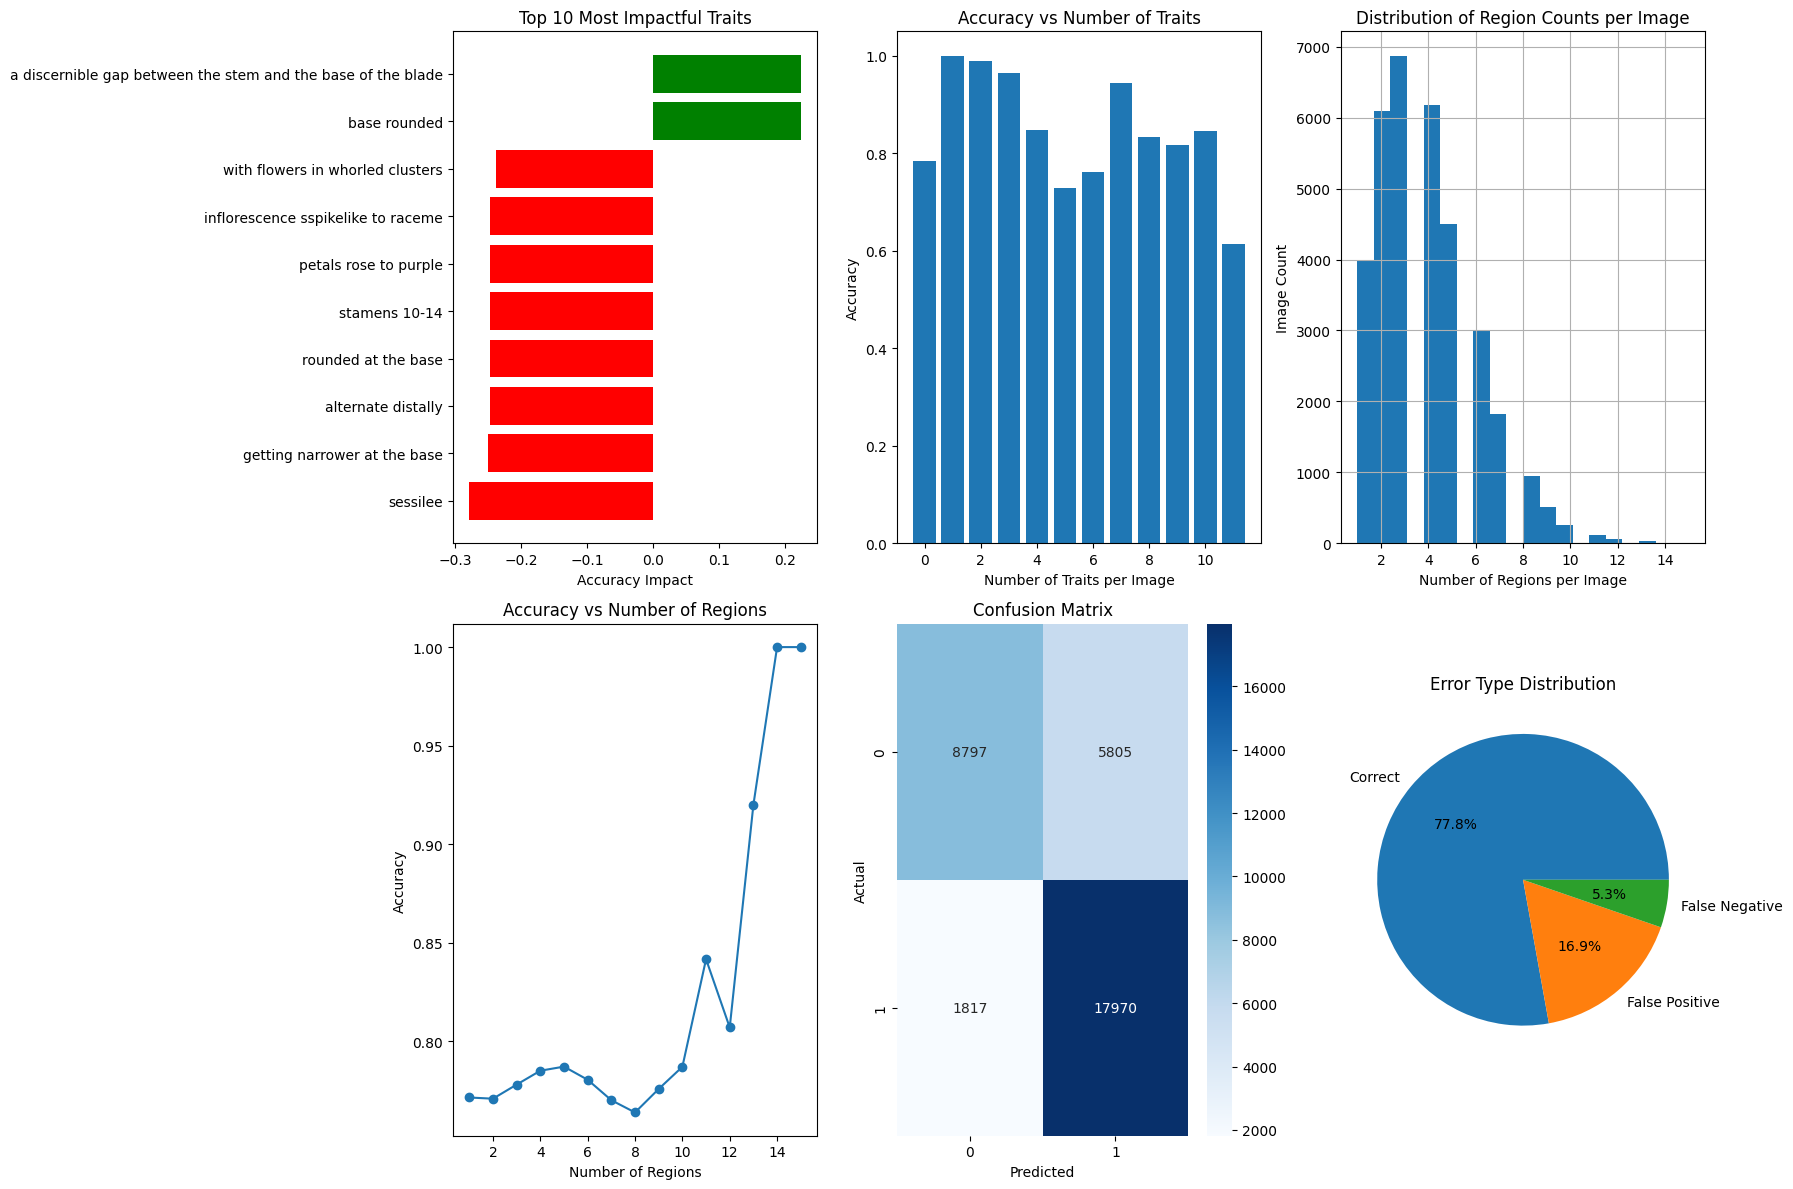

In [44]:
image_analyzer = EnhancedImageLevelAnalyzer(merged_df)

image_results = image_analyzer.comprehensive_summary_report()